### Implementing Fine Tuning Large Language Model using DialogSum Database

In [ ]:
!pip install datasets
!pip install transformers
!pip install evaluate
!pip install accelerate - U
!pip install transformers[torch]
!pip install peft

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from datasets import load_dataset
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, TrainingArguments, Trainer, GenerationConfig
import evaluate
import pandas as pd
import numpy as np

huggingface_dataset_name = "knkarthick/dialogsum"
dataset = load_dataset(huggingface_dataset_name)

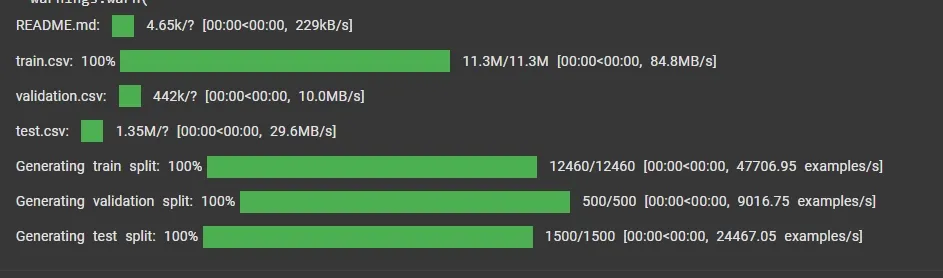

In [ ]:
model_name = "google/flan-t5-base"
base_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

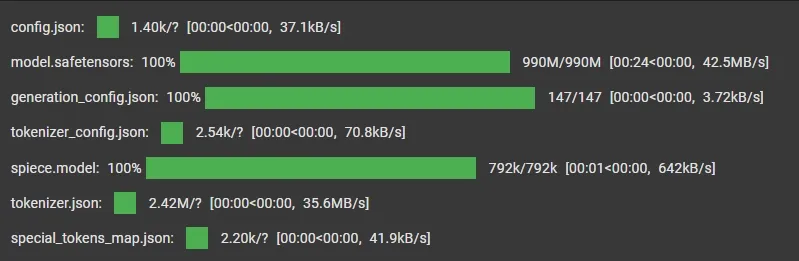

In [ ]:
def print_number_of_trainable_model_parameters(model):
    trainable_model_params = 0
    all_model_params = 0
    for _, param in model.named_parameters():
        all_model_params += param.numel()
        if param.requires_grad:
            trainable_model_params += param.numel()
    return f"trainable model parameters: {trainable_model_params}\nall model parameters: {all_model_params}\npercentage of trainable model parameters: {100 * trainable_model_params / all_model_params:.2f}%"

print(print_number_of_trainable_model_parameters(base_model))

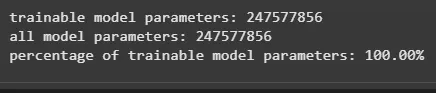

In [ ]:
i = 20
dialogue = dataset['test'][i]['dialogue']
summary = dataset['test'][i]['summary']

prompt = f"Summarize the following dialogue  {dialogue}  Summary:"

input_ids = tokenizer(prompt, return_tensors="pt").input_ids
output = tokenizer.decode(base_model.generate(input_ids, max_new_tokens=200)[0], skip_special_tokens=True)

print(f"Input Prompt : {prompt}")
print("--------------------------------------------------------------------")
print("Human evaluated summary ---->")
print(summary)
print("---------------------------------------------------------------------")
print("Baseline model generated summary : ---->")
print(output)

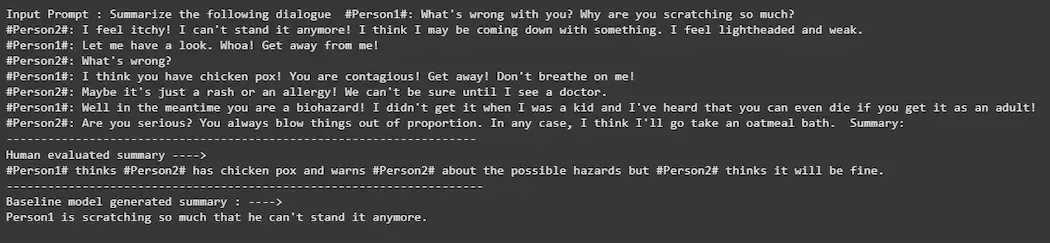

In [ ]:
def tokenize_function(example):
    start_prompt = 'Summarize the following conversation.\n\n'
    end_prompt = '\n\nSummary: '
    prompt = [start_prompt + dialogue + end_prompt for dialogue in example["dialogue"]]
    example['input_ids'] = tokenizer(prompt, padding="max_length", truncation=True, return_tensors="pt").input_ids
    example['labels'] = tokenizer(example["summary"], padding="max_length", truncation=True, return_tensors="pt").input_ids
    return example

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['id', 'topic', 'dialogue', 'summary'])
tokenized_datasets = tokenized_datasets.filter(lambda example, index: index % 100 == 0, with_indices=True)

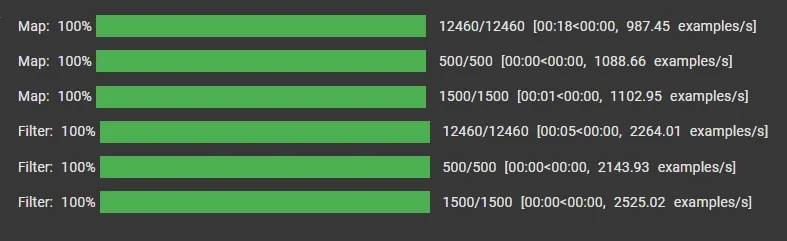

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
)

peft_model_train = get_peft_model(base_model, lora_config)
print(print_number_of_trainable_model_parameters(peft_model_train))

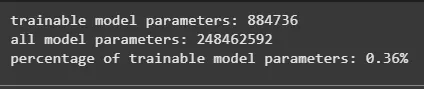

In [ ]:
output_dir = "./peft-dialogue-summary-training"

peft_training_args = TrainingArguments(
    output_dir=output_dir,
    auto_find_batch_size=True,
    learning_rate=1e-3,
    num_train_epochs=5,
)

peft_trainer = Trainer(
    model=peft_model_train,
    args=peft_training_args,
    train_dataset=tokenized_datasets["train"],
)

peft_trainer.train()



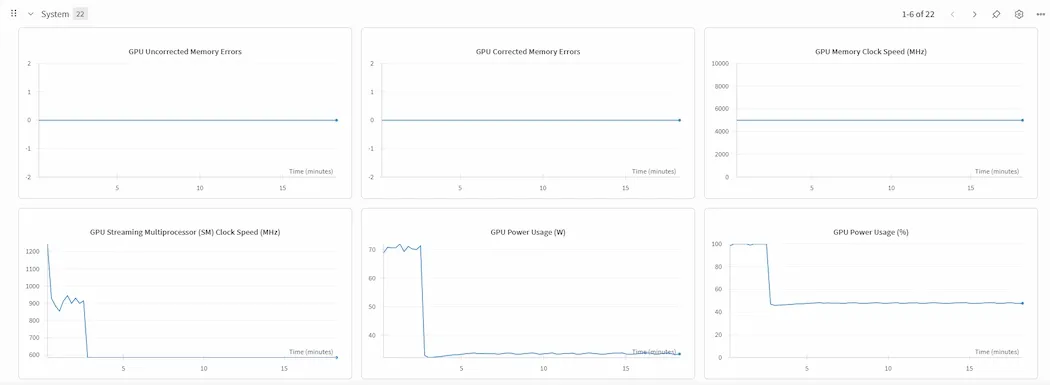